# US Diabetes Health Disparities — Exploratory Data Analysis

**Project:** US Diabetes Health Disparities Analysis  
**Data:** CDC PLACES County Data, 2025 Release  
**Author:** Adam Bailes  
**Date:** July 2026  
**Purpose:** Initial data loading and inspection of the PLACES county dataset

## How to Read This Notebook

Each code block in this notebook follows a consistent structure:

### Code Comments
Lines starting with `#` are comments — plain English explanations 
of what the code is doing. They are ignored by Python and exist 
purely for documentation.

### Explanation Cells
Each code block is accompanied by a Markdown cell (like this one) 
explaining:
- **What the code does** — the mechanics of each function or method
- **Why it is being done** — the analytical purpose and how it 
  connects to the research questions
- **What to look for in the output** — what a good result looks like 
  and what would signal a problem

### Key Python Concepts Used in This Notebook
- `pd.read_csv()` — loads a CSV file into a pandas DataFrame (a table)
- `df.shape` — returns the number of rows and columns
- `df.groupby()` — groups rows by a category for summary calculations
- `df.merge()` — joins two DataFrames on a shared column
- `df.isnull().sum()` — counts missing values per column
- `plt` / `sns` — matplotlib and seaborn, the visualization libraries
- `f'{value:.2f}'` — f-string formatting, embeds a variable value 
  into a string with 2 decimal places

### Variable Naming Convention
- `df` — the main analysis dataset (merged PLACES + Census)
- `df_*` — intermediate DataFrames (e.g., df_race, df_poverty)
- `fig, ax` — figure and axis objects for matplotlib charts

In [3]:
import pandas as pd

df = pd.read_csv(r'C:\Users\adamt\Jobs\Personal_projects\US_Diabetes_Disparities\02_data_acquisition\places_county_2025.csv')

print(df.shape)
print(df.head())

C:\Users\adamt\AppData\Local\Temp\ipykernel_37468\666703017.py:3: DtypeWarning: Columns (0: Data_Value_Footnote_Symbol, 1: Data_Value_Footnote) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(r'C:\Users\adamt\Jobs\Personal_projects\US_Diabetes_Disparities\02_data_acquisition\places_county_2025.csv')


(229298, 22)
   Year StateAbbr StateDesc LocationName DataSource         Category  \
0  2023        AR  Arkansas         Drew      BRFSS  Health Outcomes   
1  2023        AR  Arkansas       Fulton      BRFSS  Health Outcomes   
2  2023        AR  Arkansas       Howard      BRFSS  Health Outcomes   
3  2023        AR  Arkansas       Miller      BRFSS  Health Outcomes   
4  2023        AR  Arkansas     Ouachita      BRFSS       Disability   

                       Measure Data_Value_Unit   Data_Value_Type  Data_Value  \
0       Arthritis among adults               %  Crude prevalence        29.9   
1  Current asthma among adults               %  Crude prevalence        10.6   
2       Arthritis among adults               %  Crude prevalence        31.2   
3          Stroke among adults               %  Crude prevalence         4.7   
4  Any disability among adults               %  Crude prevalence        42.8   

   ... Low_Confidence_Limit High_Confidence_Limit  TotalPopulation  \
0  

In [4]:
print(df['MeasureId'].unique())

<ArrowStringArray>
[   'ARTHRITIS',      'CASTHMA',       'STROKE',   'DISABILITY',
      'OBESITY',     'DIABETES',   'DEPRESSION',      'HEARING',
        'BINGE',       'BPHIGH',       'VISION',     'MOBILITY',
     'SELFCARE',        'MHLTH',     'HIGHCHOL',        'PHLTH',
 'COLON_SCREEN',          'LPA',         'COPD',    'INDEPLIVE',
          'CHD',     'MAMMOUSE',      'CHECKUP',        'BPMED',
     'CSMOKING',   'HOUSINSECU',  'SHUTUTILITY',   'FOODINSECU',
    'TEETHLOST',        'GHLTH',     'LACKTRPT',       'CANCER',
   'EMOTIONSPT',       'DENTAL',   'LONELINESS',    'FOODSTAMP',
      'ACCESS2',    'COGNITION',   'CHOLSCREEN',        'SLEEP']
Length: 40, dtype: str


In [5]:
# Filtering down only measures needed for analysis

measures_needed = ['DIABETES', 'OBESITY', 'LPA', 'BPHIGH', 'HIGHCHOL']

df_filtered = df[df['MeasureId'].isin(measures_needed)]

print(df_filtered.shape)
print(df_filtered['MeasureId'].value_counts())

(29580, 22)
MeasureId
OBESITY     5916
DIABETES    5916
BPHIGH      5916
HIGHCHOL    5916
LPA         5916
Name: count, dtype: int64


In [6]:
df_filtered.to_csv(
    r'C:\Users\adamt\Jobs\Personal_Projects\US_Diabetes_Disparities\02_data_acquisition\places_county_2025_filtered.csv',
    index=False
)

print('Saved successfully')

Saved successfully


In [8]:
# Check for missing values

print(df_filtered.isnull().sum())

Year                              0
StateAbbr                         0
StateDesc                         0
LocationName                     10
DataSource                        0
Category                          0
Measure                           0
Data_Value_Unit                   0
Data_Value_Type                   0
Data_Value                       10
Data_Value_Footnote_Symbol    29570
Data_Value_Footnote           29570
Low_Confidence_Limit             10
High_Confidence_Limit            10
TotalPopulation                   0
TotalPop18plus                    0
LocationID                        0
CategoryID                        0
MeasureId                         0
DataValueTypeID                   0
Short_Question_Text               0
Geolocation                      10
dtype: int64


In [9]:
# Filter to rows where Data_Value is null
missing_rows = df_filtered[df_filtered['Data_Value'].isnull()]

# Print only the columns needed to identify the affected counties and measures
print(missing_rows[['StateAbbr', 'LocationName', 'LocationID', 
                     'MeasureId', 'Data_Value_Footnote']])

       StateAbbr LocationName  LocationID MeasureId  \
179442        TX       Loving       48301       LPA   
180119        TX       Loving       48301       LPA   
181005        TX       Loving       48301  DIABETES   
184841        TX       Loving       48301  HIGHCHOL   
187314        TX       Loving       48301  DIABETES   
191102        TX       Loving       48301   OBESITY   
192125        TX       Loving       48301  HIGHCHOL   
193187        TX       Loving       48301    BPHIGH   
195672        TX       Loving       48301    BPHIGH   
195815        TX       Loving       48301   OBESITY   

                                     Data_Value_Footnote  
179442  Estimates suppressed for population less than 50  
180119  Estimates suppressed for population less than 50  
181005  Estimates suppressed for population less than 50  
184841  Estimates suppressed for population less than 50  
187314  Estimates suppressed for population less than 50  
191102  Estimates suppressed for populat

In [10]:
# Drop rows where Data_Value is null (Loving County, TX - population < 50)
df_clean = df_filtered.dropna(subset=['Data_Value'])

# Confirm the rows were dropped
print(f'Rows before: {len(df_filtered)}')
print(f'Rows after: {len(df_clean)}')
print(f'Rows dropped: {len(df_filtered) - len(df_clean)}')

Rows before: 29580
Rows after: 29570
Rows dropped: 10


In [11]:
# Filter to diabetes rows only
df_diabetes = df_clean[df_clean['MeasureId'] == 'DIABETES']

# Basic descriptive statistics for diabetes prevalence
print(df_diabetes['Data_Value'].describe())

count    5914.000000
mean       12.402858
std         2.844981
min         4.900000
25%        10.300000
50%        12.100000
75%        14.000000
max        27.100000
Name: Data_Value, dtype: float64


## Note — National Mean Diabetes Prevalence

During EDA, the mean diabetes prevalence was reported as 12.4%. 
This figure was incorrect — it was calculated before filtering to 
crude prevalence only, and inadvertently averaged crude prevalence 
(13.64%) and age-adjusted prevalence (11.17%) together.

**The correct national mean crude prevalence is 13.64%** across 
2,956 matched counties in this analysis dataset.

### Crude vs Age-Adjusted Prevalence
- **Crude prevalence** — the raw percentage of adults with diagnosed 
  diabetes in a county, unadjusted for age differences
- **Age-adjusted prevalence** — statistically adjusted to remove the 
  effect of differing age distributions across counties, allowing 
  fairer comparison between younger and older populations

This analysis uses crude prevalence throughout, consistent with the 
decision documented in data_dictionary.md. Crude prevalence is 
appropriate for describing the actual burden in each county. 
Age-adjusted prevalence would be more appropriate for comparing 
counties where age structure differs substantially.

## NOTES: 
5,914 counties with a valid diabetes estimate (5,916 minus Loving County's 2 suppressed rows)

Mean of 12.4% — about 1 in 8 adults across US counties has diagnosed diabetes (see note below)

Median of 12.1% — mean and median are close, suggesting the distribution is roughly symmetric without heavy skew

Range of 4.9% to 27.1% — a substantial spread. The highest-burden counties have more than five times the prevalence of the lowest, which could be disaparity

Standard deviation of 2.8 — moderate spread around the mean

The 27.1% maximum is high, likely an outlier worth identifying — a county where more than 1 in 4 adults has diagnosed diabetes

In [12]:
# Identify the county with the highest diabetes prevalence
highest = df_diabetes[df_diabetes['Data_Value'] == df_diabetes['Data_Value'].max()]

# Print key identifying columns
print(highest[['StateAbbr', 'LocationName', 'LocationID', 'Data_Value']])

      StateAbbr LocationName  LocationID  Data_Value
11739        AL       Greene        1063        27.1


In [13]:
# Identify the county with the lowest diabetes prevalence
lowest = df_diabetes[df_diabetes['Data_Value'] == df_diabetes['Data_Value'].min()]

print(lowest[['StateAbbr', 'LocationName', 'LocationID', 'Data_Value']])

      StateAbbr LocationName  LocationID  Data_Value
44963        ID      Madison       16065         4.9


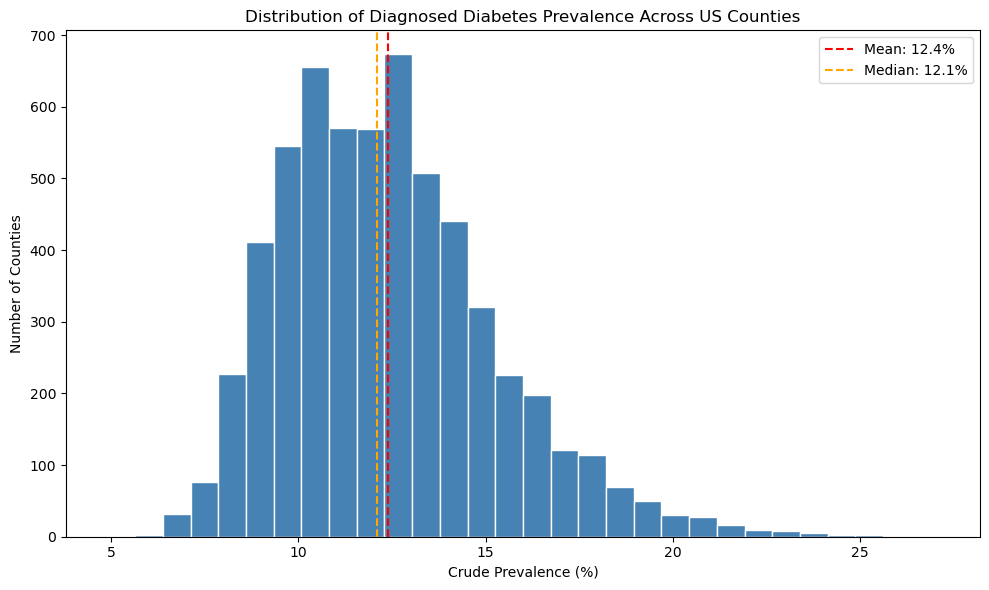

Chart saved


In [18]:
import matplotlib.pyplot as plt

# Calculate mean and median values
mean_val = df_diabetes['Data_Value'].mean()
median_val = df_diabetes['Data_Value'].median()

# Plot distribution of diabetes prevalence across all counties
plt.figure(figsize=(10, 6))
plt.hist(df_diabetes['Data_Value'], bins=30, color='steelblue', edgecolor='white')
plt.title('Distribution of Diagnosed Diabetes Prevalence Across US Counties')
plt.xlabel('Crude Prevalence (%)')
plt.ylabel('Number of Counties')

# Draw vertical lines with values in the legend
plt.axvline(mean_val, color='red', linestyle='dashed', label=f'Mean: {mean_val:.1f}%')
plt.axvline(median_val, color='orange', linestyle='dashed', label=f'Median: {median_val:.1f}%')

plt.legend()
plt.tight_layout()

# Save figure before plt.show() clears the figure from memory
plt.savefig(
    r'C:\Users\adamt\Jobs\Personal_Projects\US_Diabetes_Disparities\04_reporting\diabetes_prevalence_distribution.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()
print('Chart saved')

## NOTES

The distribution is slightly right-skewed, meaning more counties cluster at the lower end with a tail of high-burden counties pulling the mean above the median

The bulk of counties fall between 9% and 14%

The tail extending toward 25%+ represents a small number of high-burden counties that will be important in the disparity analysis

## EDA Findings — CDC PLACES Diabetes Prevalence

- 5,914 counties with valid diabetes estimates after excluding Loving County, TX
- Mean prevalence: 12.4%, Median: 12.1% — distribution slightly right-skewed
- Range: 4.9% (Madison County, ID) to 27.1% (Greene County, AL)
- Tail of high-burden counties above 20% will be important in disparity analysis

In [19]:
# Descriptive statistics for all five measures
for measure in measures_needed:
    subset = df_clean[df_clean['MeasureId'] == measure]
    print(f'\n{measure}')
    print(subset['Data_Value'].describe().round(1))


DIABETES
count    5914.0
mean       12.4
std         2.8
min         4.9
25%        10.3
50%        12.1
75%        14.0
max        27.1
Name: Data_Value, dtype: float64

OBESITY
count    5914.0
mean       37.5
std         4.8
min        16.7
25%        35.0
50%        38.1
75%        40.5
max        54.0
Name: Data_Value, dtype: float64

LPA
count    5914.0
mean       27.7
std         5.5
min        12.1
25%        24.0
50%        27.3
75%        31.2
max        49.5
Name: Data_Value, dtype: float64

BPHIGH
count    5914.0
mean       36.1
std         5.7
min        17.3
25%        31.8
50%        35.7
75%        39.8
max        59.8
Name: Data_Value, dtype: float64

HIGHCHOL
count    5914.0
mean       35.1
std         4.2
min        21.2
25%        32.0
50%        34.5
75%        38.3
max        51.4
Name: Data_Value, dtype: float64


Burden levels:

- Obesity (37.5%), high blood pressure (36.1%), and high cholesterol (35.1%) all cluster around 35-38% mean prevalence — roughly 1 in 3 adults across counties
- Physical inactivity (27.7%) is somewhat lower
- Diabetes (12.4%) is the lowest, as expected since it is an outcome of the risk factors above

Spread (standard deviation):

- BPHIGH has the widest spread (std 5.7) followed closely by LPA (5.5), meaning these two measures vary the most across counties
- HIGHCHOL has the narrowest spread (4.2), meaning it is more uniform across the country
- Wider spread is generally more useful for disparity analysis since it means there is more variation to explain

Range:

- BPHIGH has a striking range: 17.3% to 59.8%, nearly a 43 percentage point gap across counties
- LPA (low physical activity) ranges from 12.1% to 49.5% — also very wide
- These ranges signal that geography is strongly associated with these measures, which is exactly what the disparity analysis will explore

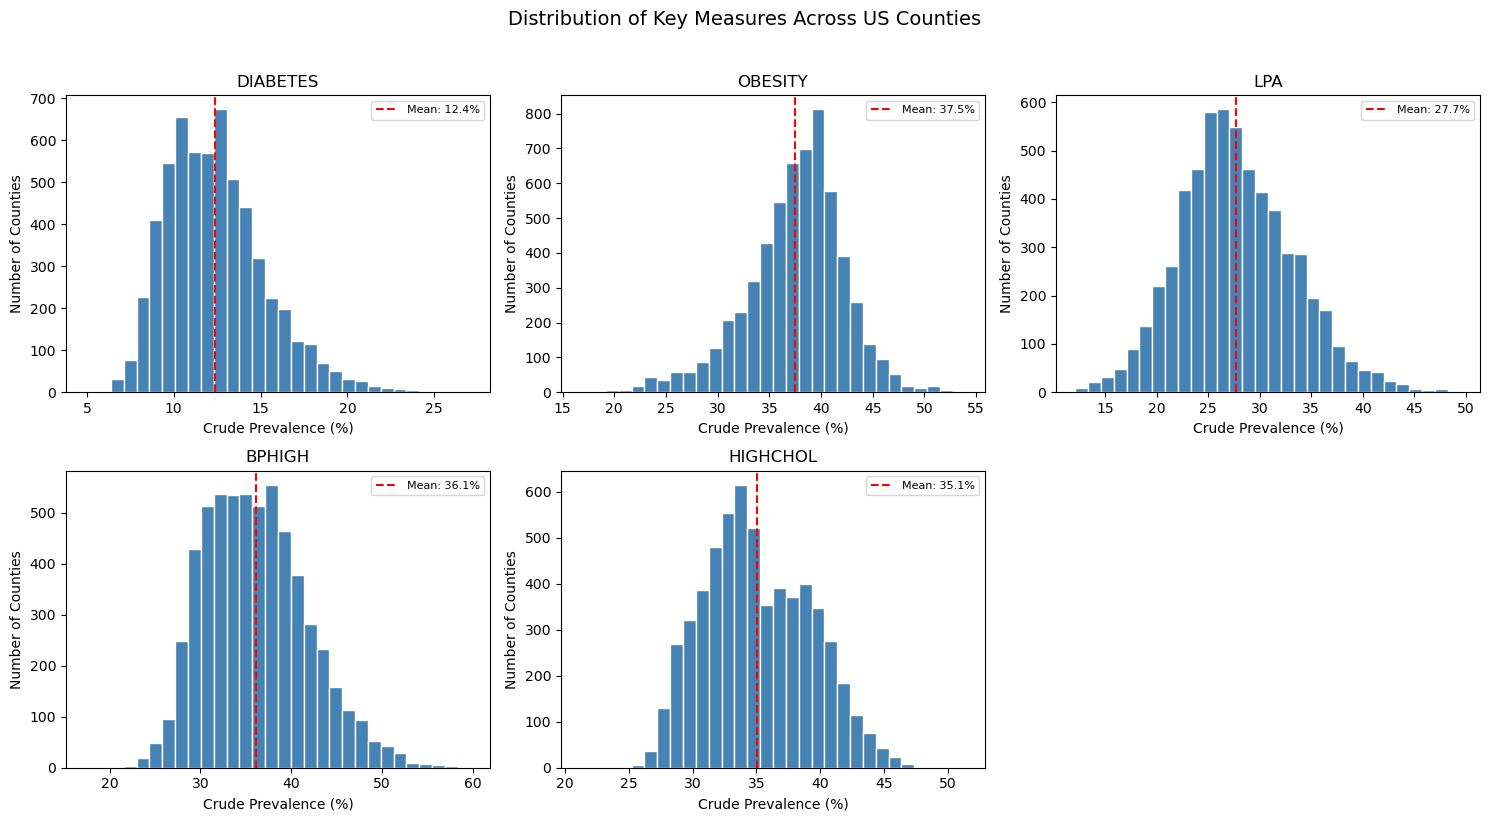

Chart saved


In [20]:
# Plot distributions for all five measures in a single figure
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

# Flatten axes array for easier iteration
axes = axes.flatten()

# Loop through each measure and plot on its own subplot
for i, measure in enumerate(measures_needed):
    subset = df_clean[df_clean['MeasureId'] == measure]
    mean_val = subset['Data_Value'].mean()
    
    axes[i].hist(subset['Data_Value'], bins=30, 
                 color='steelblue', edgecolor='white')
    axes[i].axvline(mean_val, color='red', linestyle='dashed', 
                    label=f'Mean: {mean_val:.1f}%')
    axes[i].set_title(measure)
    axes[i].set_xlabel('Crude Prevalence (%)')
    axes[i].set_ylabel('Number of Counties')
    axes[i].legend(fontsize=8)

# Hide the sixth subplot since there are only 5 measures
axes[5].set_visible(False)

plt.suptitle('Distribution of Key Measures Across US Counties', 
             fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(
    r'C:\Users\adamt\Jobs\Personal_Projects\US_Diabetes_Disparities\04_reporting\all_measures_distribution.png',
    dpi=150, bbox_inches='tight'
)
plt.show()
print('Chart saved')

## EDA Findings — All Five Measures

| Measure | Mean | Std | Min | Max |
|---------|------|-----|-----|-----|
| DIABETES | 12.4% | 2.8 | 4.9% | 27.1% |
| OBESITY | 37.5% | 4.8 | 16.7% | 54.0% |
| LPA | 27.7% | 5.5 | 12.1% | 49.5% |
| BPHIGH | 36.1% | 5.7 | 17.3% | 59.8% |
| HIGHCHOL | 35.1% | 4.2 | 21.2% | 51.4% |

- All five measures show right skew with high-burden county tails
- BPHIGH has the widest range (42.5 percentage points)
- LPA shows the greatest spread relative to its mean

## NEXT STEP

The next step is to look at how the five measures correlate with each other across counties. This matters because if obesity, physical inactivity, and high blood pressure all move together with diabetes, that pattern strengthens the case for a shared set of underlying determinants — which is the structural argument behind the disparity analysis.

To do this the data needs to be reshaped first. Right now df_clean is in long format with one row per county per measure. Correlation analysis needs wide format — one row per county with each measure as its own column.

In [21]:
# Pivot from long to wide format — one row per county, one column per measure
df_wide = df_clean.pivot_table(
    index='LocationID',
    columns='MeasureId',
    values='Data_Value'
).reset_index()

# Confirm the shape and preview
print(df_wide.shape)
print(df_wide.head())

(2957, 6)
MeasureId  LocationID  BPHIGH  DIABETES  HIGHCHOL    LPA  OBESITY
0                  59   32.55     11.15     34.80  24.10    32.85
1                1001   40.10     12.35     38.80  26.50    39.65
2                1003   40.40     11.90     39.10  24.55    35.10
3                1005   47.80     18.05     39.75  35.35    46.95
4                1007   44.35     15.05     39.55  32.60    43.80


In [22]:
# Check for duplicate county/measure combinations
duplicates = df_clean.groupby(['LocationID', 'MeasureId']).size()

# Show any combinations with more than one row
print(duplicates[duplicates > 1].head(20))

LocationID  MeasureId
59          BPHIGH       2
            DIABETES     2
            HIGHCHOL     2
            LPA          2
            OBESITY      2
1001        BPHIGH       2
            DIABETES     2
            HIGHCHOL     2
            LPA          2
            OBESITY      2
1003        BPHIGH       2
            DIABETES     2
            HIGHCHOL     2
            LPA          2
            OBESITY      2
1005        BPHIGH       2
            DIABETES     2
            HIGHCHOL     2
            LPA          2
            OBESITY      2
dtype: int64


## NOTE
The .cvs file showed there is a crude prevalence and an age adjusted prevalence for every county

In [23]:
# Filter to crude prevalence only before pivoting
# The analysis plan already specifies crude prevalence as the measure type for this project, 
# so this filter is consistent with documented analytical decisions.

df_crude = df_clean[df_clean['Data_Value_Type'] == 'Crude prevalence']

# Confirm the row count is halved
print(df_crude.shape)

(14785, 22)


In [24]:
# Pivot to wide format using crude prevalence only
df_wide = df_crude.pivot_table(
    index='LocationID',
    columns='MeasureId',
    values='Data_Value'
).reset_index()

print(df_wide.shape)
print(df_wide.head())

(2957, 6)
MeasureId  LocationID  BPHIGH  DIABETES  HIGHCHOL   LPA  OBESITY
0                  59    34.4      12.0      37.4  24.5     32.8
1                1001    42.0      13.3      41.3  27.0     39.8
2                1003    43.8      13.4      42.8  25.4     35.2
3                1005    50.2      19.6      43.0  36.2     46.8
4                1007    46.3      16.2      42.4  33.3     43.9


Correlation Analysis: calculate the Pearson correlation coefficient between every pair of columns. The result is a 5x5 matrix where each cell shows how strongly two measures move together across counties. Values range from -1 to 1:

1.0 means perfectly positively correlated

0.0 means no linear relationship

-1.0 means perfectly negatively correlated

In [25]:
# Calculate correlation matrix across the five measures
correlation_matrix = df_wide[['DIABETES', 'OBESITY', 'LPA', 'BPHIGH', 'HIGHCHOL']].corr()

print(correlation_matrix.round(2))

MeasureId  DIABETES  OBESITY   LPA  BPHIGH  HIGHCHOL
MeasureId                                           
DIABETES       1.00     0.67  0.85    0.89      0.68
OBESITY        0.67     1.00  0.75    0.66      0.38
LPA            0.85     0.75  1.00    0.75      0.52
BPHIGH         0.89     0.66  0.75    1.00      0.81
HIGHCHOL       0.68     0.38  0.52    0.81      1.00


Strongest relationships with DIABETES:

- PHIGH: 0.89 - very strong. High blood pressure and diabetes co-occur at the county level almost as strongly as any two measures in the dataset
- LPA: 0.85 - physical inactivity is nearly as strong a correlate as blood pressure
- OBESITY: 0.67 - moderate, which is somewhat surprising given the well-established biological link. Suggests other factors beyond obesity are driving county-level diabetes variation
- HIGHCHOL: 0.68 - similar to obesity

Other notable patterns:

- BPHIGH and HIGHCHOL: 0.81 - strong, consistent with cardiovascular risk clustering
- OBESITY and HIGHCHOL: 0.38 - the weakest relationship in the matrix, worth noting

The LPA/DIABETES correlation of 0.85 is the most analytically interesting finding here. It suggests that counties with high physical inactivity have substantially higher diabetes burden, independent of obesity - which points toward structural and environmental factors like walkability, access to recreational facilities, and neighborhood safety rather than individual behavior alone. That framing connects directly to the equity argument in the analysis plan.

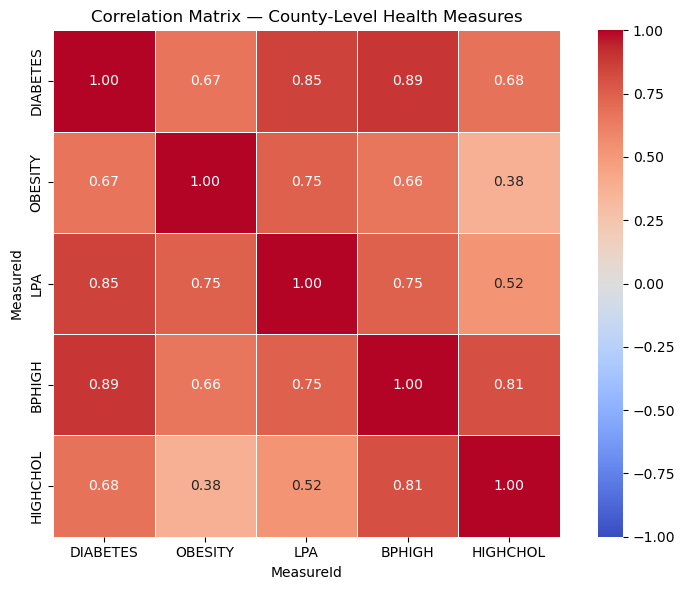

Chart saved


In [26]:
import seaborn as sns

# Plot correlation heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.5
)
plt.title('Correlation Matrix — County-Level Health Measures')
plt.tight_layout()
plt.savefig(
    r'C:\Users\adamt\Jobs\Personal_Projects\US_Diabetes_Disparities\04_reporting\correlation_heatmap.png',
    dpi=150, bbox_inches='tight'
)
plt.show()
print('Chart saved')

## EDA Findings — Correlation Analysis

- All five measures are positively correlated at the county level
- DIABETES correlates most strongly with BPHIGH (0.89) and LPA (0.85)
- DIABETES correlates more weakly with OBESITY (0.67) than expected
  given the established biological relationship
- OBESITY/HIGHCHOL shows the weakest relationship in the matrix (0.38)
- The LPA/DIABETES correlation (0.85) suggests structural and environmental
  factors beyond individual behavior are driving county-level patterns

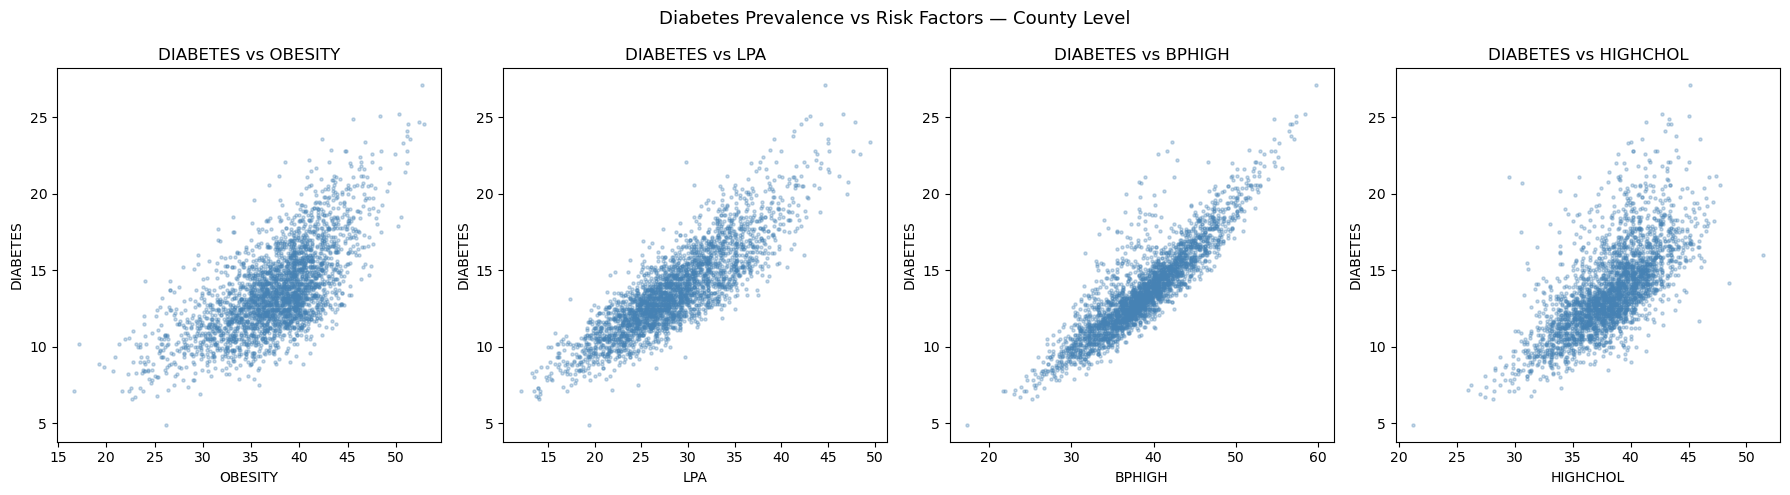

Chart saved


In [27]:
# Scatter plot matrix — each measure plotted against diabetes prevalence
fig, axes = plt.subplots(1, 4, figsize=(18, 5))

# Define the four measures to plot against diabetes
comparisons = ['OBESITY', 'LPA', 'BPHIGH', 'HIGHCHOL']

for i, measure in enumerate(comparisons):
    axes[i].scatter(df_wide[measure], df_wide['DIABETES'], 
                    alpha=0.3, s=5, color='steelblue')
    axes[i].set_xlabel(measure)
    axes[i].set_ylabel('DIABETES')
    axes[i].set_title(f'DIABETES vs {measure}')

plt.suptitle('Diabetes Prevalence vs Risk Factors — County Level', 
             fontsize=13)
plt.tight_layout()
plt.savefig(
    r'C:\Users\adamt\Jobs\Personal_Projects\US_Diabetes_Disparities\04_reporting\scatter_matrix.png',
    dpi=150, bbox_inches='tight'
)
plt.show()
print('Chart saved')

**Note — Linearity assumption to be verified:**
Relationships appear approximately linear across the mid-range of values.
However, non-linearity at higher burden levels is plausible given
compounding risk factors in high-deprivation counties. Formal linearity
checks (residual plots, polynomial terms) to be conducted in
02_feature_transformation.ipynb before regression modeling.

## Census / ACS Data Acquisition

- Source: American Community Survey (ACS) 5-Year Estimates, 2023
- API access via the Census Python library
- Tables pulled: B02001 (Race), S1701 (Poverty / Income)
- Geographic level: County (all US counties)
- Join key: FIPS code (state + county concatenated)

### Variables — Race & Ethnicity (B02001)
- B02001_001E: Total population
- B02001_002E: White alone
- B02001_003E: Black or African American alone
- B02001_004E: American Indian and Alaska Native alone
- B02001_005E: Asian alone
- B02001_006E: Native Hawaiian and Other Pacific Islander alone
- B02001_008E: Two or more races

**Note:** Hispanic/Latino ethnicity is a separate Census concept and
requires a different table (B03003). To be added in feature
transformation notebook.

In [29]:
import subprocess
subprocess.run(['pip', 'install', 'census'], check=True)

CompletedProcess(args=['pip', 'install', 'census'], returncode=0)

In [30]:
from census import Census

# Initialize the Census API connection — regenerate key before pushing to GitHub
api_key = '18b6f04b3b026ec208981ae2d9a98049393932b8'
c = Census(api_key)

print('Census API connected')

Census API connected


In [31]:
# Pull race/ethnicity data from ACS 5-year estimates (2023)
# B02001 is the Census table for race counts by county
race_data = c.acs5.get(
    ('NAME',
     'B02001_001E',  # Total population
     'B02001_002E',  # White alone
     'B02001_003E',  # Black or African American alone
     'B02001_004E',  # American Indian and Alaska Native alone
     'B02001_005E',  # Asian alone
     'B02001_006E',  # Native Hawaiian and Other Pacific Islander alone
     'B02001_008E'), # Two or more races
    {'for': 'county:*', 'in': 'state:*'},
    year=2023
)

print(f'Rows returned: {len(race_data)}')
print(race_data[0])

Rows returned: 3222
{'NAME': 'Autauga County, Alabama', 'B02001_001E': 59285.0, 'B02001_002E': 43616.0, 'B02001_003E': 11829.0, 'B02001_004E': 42.0, 'B02001_005E': 616.0, 'B02001_006E': 0.0, 'B02001_008E': 2722.0, 'state': '01', 'county': '001'}


In [32]:
# Convert API response to a DataFrame
df_race = pd.DataFrame(race_data)

# Concatenate state and county codes into a single 5-digit FIPS code
# This must match the LocationID column in df_wide
df_race['LocationID'] = df_race['state'] + df_race['county']

# Preview the result
print(df_race.shape)
print(df_race.head())

(3222, 11)
                      NAME  B02001_001E  B02001_002E  B02001_003E  \
0  Autauga County, Alabama      59285.0      43616.0      11829.0   
1  Baldwin County, Alabama     239945.0     198721.0      19144.0   
2  Barbour County, Alabama      24757.0      10891.0      11616.0   
3     Bibb County, Alabama      22152.0      16634.0       4587.0   
4   Blount County, Alabama      59292.0      53062.0        747.0   

   B02001_004E  B02001_005E  B02001_006E  B02001_008E state county LocationID  
0         42.0        616.0          0.0       2722.0    01    001      01001  
1        980.0       2272.0        104.0      13284.0    01    003      01003  
2         46.0        136.0          0.0        731.0    01    005      01005  
3        175.0         51.0          0.0        625.0    01    007      01007  
4        235.0         51.0         88.0       3054.0    01    009      01009  


In [33]:
# Rename columns to meaningful names
df_race = df_race.rename(columns={
    'B02001_001E': 'pop_total',
    'B02001_002E': 'pop_white',
    'B02001_003E': 'pop_black',
    'B02001_004E': 'pop_aian',
    'B02001_005E': 'pop_asian',
    'B02001_006E': 'pop_nhpi',
    'B02001_008E': 'pop_multirace'
})

# Drop the separate state and county columns since LocationID covers both
df_race = df_race.drop(columns=['state', 'county'])

print(df_race.head())

                      NAME  pop_total  pop_white  pop_black  pop_aian  \
0  Autauga County, Alabama    59285.0    43616.0    11829.0      42.0   
1  Baldwin County, Alabama   239945.0   198721.0    19144.0     980.0   
2  Barbour County, Alabama    24757.0    10891.0    11616.0      46.0   
3     Bibb County, Alabama    22152.0    16634.0     4587.0     175.0   
4   Blount County, Alabama    59292.0    53062.0      747.0     235.0   

   pop_asian  pop_nhpi  pop_multirace LocationID  
0      616.0       0.0         2722.0      01001  
1     2272.0     104.0        13284.0      01003  
2      136.0       0.0          731.0      01005  
3       51.0       0.0          625.0      01007  
4       51.0      88.0         3054.0      01009  


In [35]:
# Pull poverty data from ACS 5-year Subject Table S1701
# acs5st accesses subject tables, which acs5 does not support
poverty_data = c.acs5st.get(
    ('NAME',
     'S1701_C01_001E',  # Total population for poverty determination
     'S1701_C02_001E',  # Population below poverty level
     'S1701_C03_001E'),  # Percent below poverty level
    {'for': 'county:*', 'in': 'state:*'},
    year=2023
)

print(f'Rows returned: {len(poverty_data)}')
print(poverty_data[0])

Rows returned: 3222
{'NAME': 'Autauga County, Alabama', 'S1701_C01_001E': 58731.0, 'S1701_C02_001E': 6275.0, 'S1701_C03_001E': 10.7, 'state': '01', 'county': '001'}


In [36]:
# Convert to DataFrame
df_poverty = pd.DataFrame(poverty_data)

# Build 5-digit FIPS code to match LocationID in df_wide
df_poverty['LocationID'] = df_poverty['state'] + df_poverty['county']

# Rename columns to meaningful names
df_poverty = df_poverty.rename(columns={
    'S1701_C01_001E': 'pop_poverty_total',
    'S1701_C02_001E': 'pop_below_poverty',
    'S1701_C03_001E': 'pct_below_poverty'
})

# Drop separate state and county columns
df_poverty = df_poverty.drop(columns=['state', 'county'])

print(df_poverty.shape)
print(df_poverty.head())

(3222, 5)
                      NAME  pop_poverty_total  pop_below_poverty  \
0  Autauga County, Alabama            58731.0             6275.0   
1  Baldwin County, Alabama           236041.0            24819.0   
2  Barbour County, Alabama            21650.0             4746.0   
3     Bibb County, Alabama            20759.0             4258.0   
4   Blount County, Alabama            58665.0             8269.0   

   pct_below_poverty LocationID  
0               10.7      01001  
1               10.5      01003  
2               21.9      01005  
3               20.5      01007  
4               14.1      01009  


In [37]:
# Pull median household income from ACS 5-year estimates (2023)
# B19013_001E is median household income in the past 12 months
income_data = c.acs5.get(
    ('NAME',
     'B19013_001E'),  # Median household income
    {'for': 'county:*', 'in': 'state:*'},
    year=2023
)

print(f'Rows returned: {len(income_data)}')
print(income_data[0])

Rows returned: 3222
{'NAME': 'Autauga County, Alabama', 'B19013_001E': 69841.0, 'state': '01', 'county': '001'}


In [38]:
# Convert to DataFrame
df_income = pd.DataFrame(income_data)

# Build 5-digit FIPS code
df_income['LocationID'] = df_income['state'] + df_income['county']

# Rename column to meaningful name
df_income = df_income.rename(columns={
    'B19013_001E': 'median_household_income'
})

# Drop separate state and county columns
df_income = df_income.drop(columns=['state', 'county'])

print(df_income.shape)
print(df_income.head())

(3222, 3)
                      NAME  median_household_income LocationID
0  Autauga County, Alabama                  69841.0      01001
1  Baldwin County, Alabama                  75019.0      01003
2  Barbour County, Alabama                  44290.0      01005
3     Bibb County, Alabama                  51215.0      01007
4   Blount County, Alabama                  61096.0      01009


In [39]:
# Save Census data pulls to CSV files in 02_data_acquisition
path = r'C:\Users\adamt\Jobs\Personal_Projects\US_Diabetes_Disparities\02_data_acquisition\\'

df_race.to_csv(path + 'census_race_2023.csv', index=False)
df_poverty.to_csv(path + 'census_poverty_2023.csv', index=False)
df_income.to_csv(path + 'census_income_2023.csv', index=False)

print('All three Census files saved')

All three Census files saved
